# OLMo-2-1B × opc-sft-stage2 leaderboard — long-horizon (r=64, 9000 steps, ~225M tokens)

Long-horizon characterization from `docs/notes/polar_product/tight_chord_paper_plan.md` (Phase L). Cell: OLMo-2-1B × `opc-sft-stage2` (4 sub-configs concat, 436k docs → 150k packed slots @ seq=2048) × r=64 × global_batch=16 (batch=4 × accum=4) × packed_v1 × constant LR × α=r × all-linear × bf16 × compile × single-GPU Blackwell. `max_steps=9000` ≈ 225M unique content tokens (~295M slot-tokens at 75% fill).

Source label: **OLMo OPC eval JSONL logs**: `allenai/OLMo-2-0425-1B`; `data/opc_sft_stage2_all_packed_seq2048`; `packed_v1` / `packed_v1.1`; seq2048; 9k-step eval logs.

Diagnostic q_agree source: **OLMo OPC JSONL q_agree**: `optim_step.awc_q_agree_*` from `logs/chord_tight_slack_phase_L_1b_r256_lr2_blackwell` (r256, ns=5, lr={3e-3,1e-2}). These are JSONL diagnostics, not snapshot-registry rows.

Phase L LR sweep, seed=0, three optimizer arms. AdamW + chord-tight each pool three sub-sweeps (original L1, packed-v1.1 repack of same η values, η-extension); chord-tight-clean κ_sr=0.75 is a single sub-sweep added 2026-05-26 to test whether the packed_v1 Magicoder winner transfers.

- **AdamW**: η ∈ {3e-5, 1e-4, 3e-4, 1e-3, 3e-3}
- **chord-tight (polar, k=1)** (`adam-polar-product-lora-coupled-spectral-chord-tight`): η ∈ {3e-3, 1e-2, 3e-2, 1e-1, 3e-1}
- **chord-tight-clean κ_sr=0.75** (`adam-polar-product-lora-coupled-spectral-chord-tight-clean`, polar_method=ssc, ssc_kappa_solver=stable_rank, picard=2): η ∈ {1e-3, 3e-3, 1e-2, 3e-2, 1e-1}

Source log groups: `{adamw,chord_tight}_phase_L_lrsweep_r64_{blackwell,repack_blackwell,extension_blackwell}`, `chord_tight_clean_ssc_kappa075_phase_L_lrsweep_r64_blackwell`.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Repo root by marker-walk, so this notebook works from any subdir.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'lora_playground').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.plotting import leaderboard_panel, canonical_label

# Run membership comes from the shared registry (lora_playground.workloads) — the
# SAME source the leaderboard doc uses, so notebook and doc cannot drift. Cells are
# leaderboard_panel(model, dataset, rank, ...) + an optional label_filter(label, cfg).

def ns_of(cfg):
    oc = cfg.get('optimizer_config') or {}
    return cfg.get('muon_ns_steps', oc.get('ns_steps'))

def picard_of(cfg):
    return cfg.get('_derived', {}).get('effective_picard_iters', cfg.get('picard_iters_override')) or 1

def is_curv(label):
    # curvature-whitening / SOAP-curv / KL-Shampoo arms.
    return ('SOAP-curv' in label) or ('KL-Shampoo' in label) or ('+curv' in label)

## r=64 — k=1 family


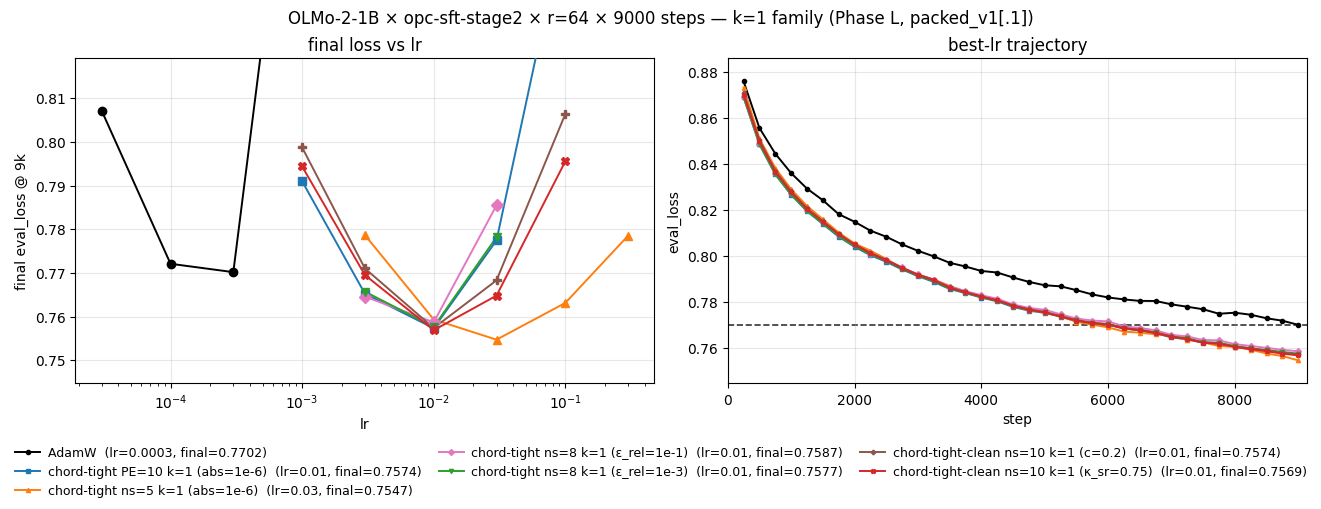

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0003,0.770190,NaN,NaN
1,chord-tight PE=10 k=1 (abs=1e-6),0.0100,0.757365,-0.012825,-7.544177
2,chord-tight ns=5 k=1 (abs=1e-6),0.0300,0.754735,-0.015455,-9.091285
3,chord-tight ns=8 k=1 (ε_rel=1e-1),0.0100,0.758707,-0.011483,-6.754519
4,chord-tight ns=8 k=1 (ε_rel=1e-3),0.0100,0.757655,-0.012535,-7.373303
5,chord-tight-clean ns=10 k=1 (c=0.2),0.0100,0.757394,-0.012796,-7.526837
6,chord-tight-clean ns=10 k=1 (κ_sr=0.75),0.0100,0.756905,-0.013285,-7.814931


In [2]:
_fig, _tdf, sdf = leaderboard_panel('allenai/OLMo-2-0425-1B', 'opc', 64,
    'OLMo-2-1B × opc-sft-stage2 × r=64 × 9000 steps — k=1 family (Phase L, packed_v1[.1])',
    label_filter=lambda l, c: l == 'AdamW' or (picard_of(c) == 1 and not is_curv(l)),
    figsize=(13, 5))
plt.show()
sdf

## r=64 — k=2 (picard) family


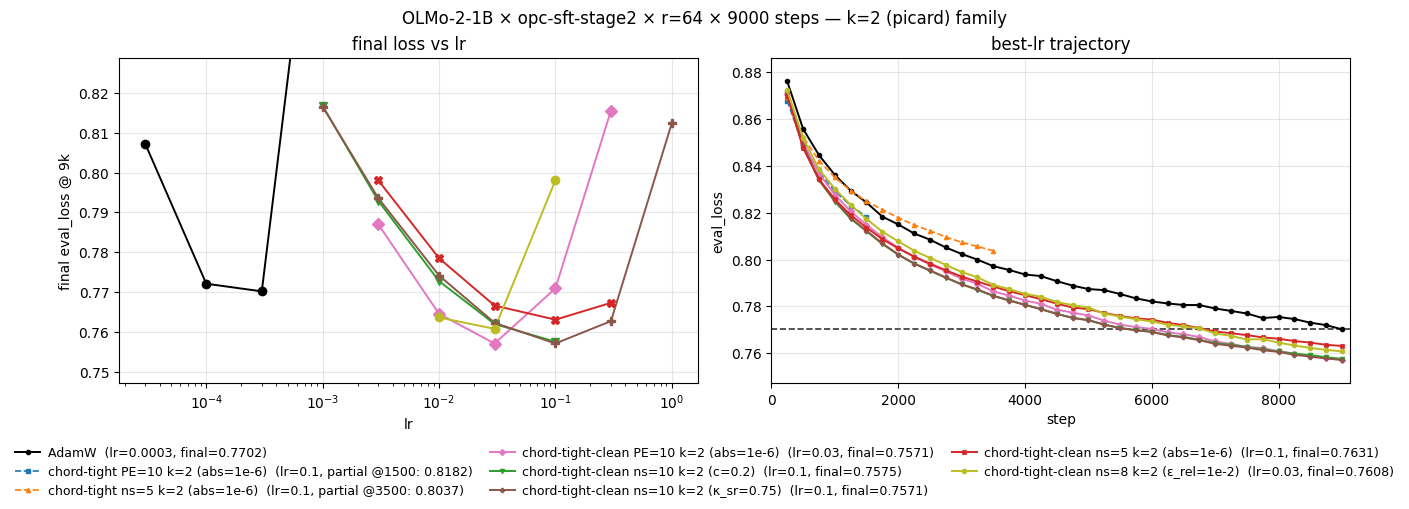

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0003,0.770190,NaN,NaN
1,chord-tight-clean PE=10 k=2 (abs=1e-6),0.0300,0.757100,-0.013090,-7.700211
2,chord-tight-clean ns=10 k=2 (c=0.2),0.1000,0.757536,-0.012654,-7.443482
3,chord-tight-clean ns=10 k=2 (κ_sr=0.75),0.1000,0.757113,-0.013077,-7.692083
4,chord-tight-clean ns=5 k=2 (abs=1e-6),0.1000,0.763085,-0.007105,-4.179447
5,chord-tight-clean ns=8 k=2 (ε_rel=1e-2),0.0300,0.760779,-0.009411,-5.536016


In [3]:
_fig, _tdf, sdf = leaderboard_panel('allenai/OLMo-2-0425-1B', 'opc', 64,
    'OLMo-2-1B × opc-sft-stage2 × r=64 × 9000 steps — k=2 (picard) family',
    label_filter=lambda l, c: l == 'AdamW' or (picard_of(c) == 2 and not is_curv(l)),
    figsize=(13, 5))
plt.show()
sdf

## r=256 — k=1 family (rank-extension robustness)


In [4]:
# r=256 panels below — data pulled per-cell from the registry (no separate load).

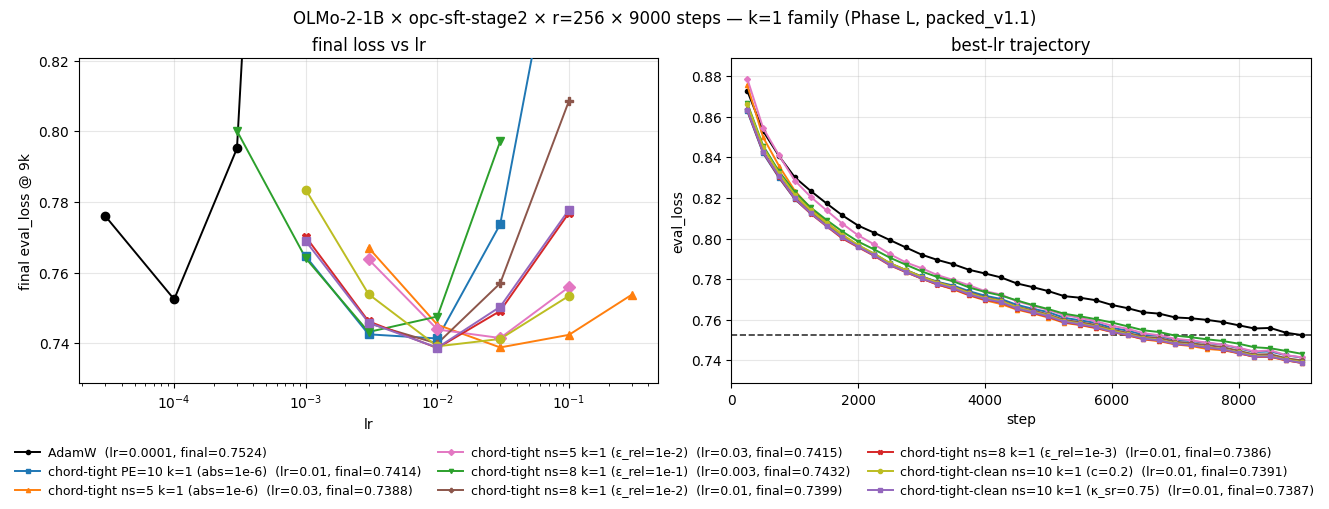

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.752439,NaN,NaN
1,chord-tight PE=10 k=1 (abs=1e-6),0.0100,0.741352,-0.011087,-6.521472
2,chord-tight ns=5 k=1 (abs=1e-6),0.0300,0.738814,-0.013625,-8.014693
3,chord-tight ns=5 k=1 (ε_rel=1e-2),0.0300,0.741482,-0.010956,-6.444879
4,chord-tight ns=8 k=1 (ε_rel=1e-1),0.0030,0.743191,-0.009248,-5.439932
5,chord-tight ns=8 k=1 (ε_rel=1e-2),0.0100,0.739923,-0.012515,-7.362019
6,chord-tight ns=8 k=1 (ε_rel=1e-3),0.0100,0.738640,-0.013799,-8.116987
7,chord-tight-clean ns=10 k=1 (c=0.2),0.0100,0.739125,-0.013314,-7.831523
8,chord-tight-clean ns=10 k=1 (κ_sr=0.75),0.0100,0.738747,-0.013692,-8.053865


In [5]:
_fig, _tdf, sdf = leaderboard_panel('allenai/OLMo-2-0425-1B', 'opc', 256,
    'OLMo-2-1B × opc-sft-stage2 × r=256 × 9000 steps — k=1 family (Phase L, packed_v1.1)',
    label_filter=lambda l, c: l == 'AdamW' or (picard_of(c) == 1 and not is_curv(l)),
    figsize=(13, 5))
plt.show()
sdf

## r=256 — curvature-whitening A/B (k=1)

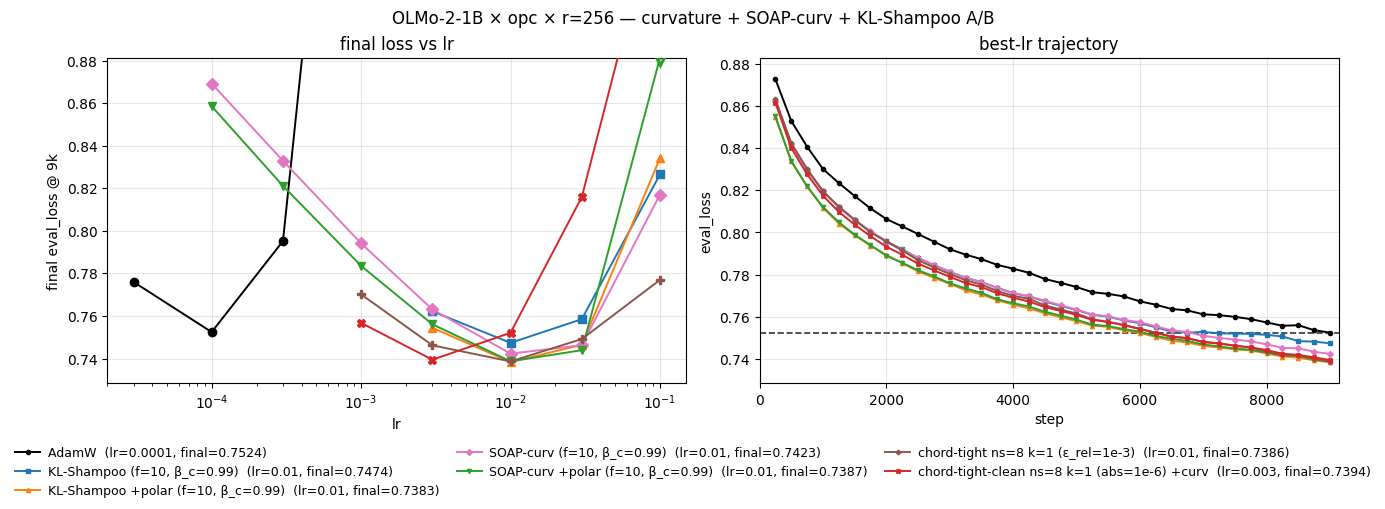

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.752439,NaN,NaN
1,"KL-Shampoo (f=10, β_c=0.99)",0.0100,0.747365,-0.005074,-7.248817
2,"KL-Shampoo +polar (f=10, β_c=0.99)",0.0100,0.738331,-0.014108,-20.153889
3,"SOAP-curv (f=10, β_c=0.99)",0.0100,0.742281,-0.010158,-14.510805
4,"SOAP-curv +polar (f=10, β_c=0.99)",0.0100,0.738704,-0.013734,-19.620372
5,chord-tight ns=8 k=1 (ε_rel=1e-3),0.0100,0.738640,-0.013799,-19.712683
6,chord-tight-clean ns=8 k=1 (abs=1e-6) +curv,0.0030,0.739445,-0.012994,-18.562544


In [6]:
# Curvature-whitening / SOAP-curv / KL-Shampoo A/B at r=256 (full-polar curvature
# whitening, SOAP-on-m in S⊗D, KL-Shampoo coupled curvature). Filtered view of
# the r=256 cell; sigma_ref is the tighter r=256 anchor.
_fig, _tdf, sdf = leaderboard_panel('allenai/OLMo-2-0425-1B', 'opc', 256,
    'OLMo-2-1B × opc × r=256 — curvature + SOAP-curv + KL-Shampoo A/B',
    label_filter=lambda l, c: l == 'AdamW' or is_curv(l),
    baselines=['chord-tight ns=8 k=1 (ε_rel=1e-3)'],
    sigma_ref=0.0007,
    figsize=(13, 5))
plt.show()
sdf

## r=256 — k=2 (picard) family


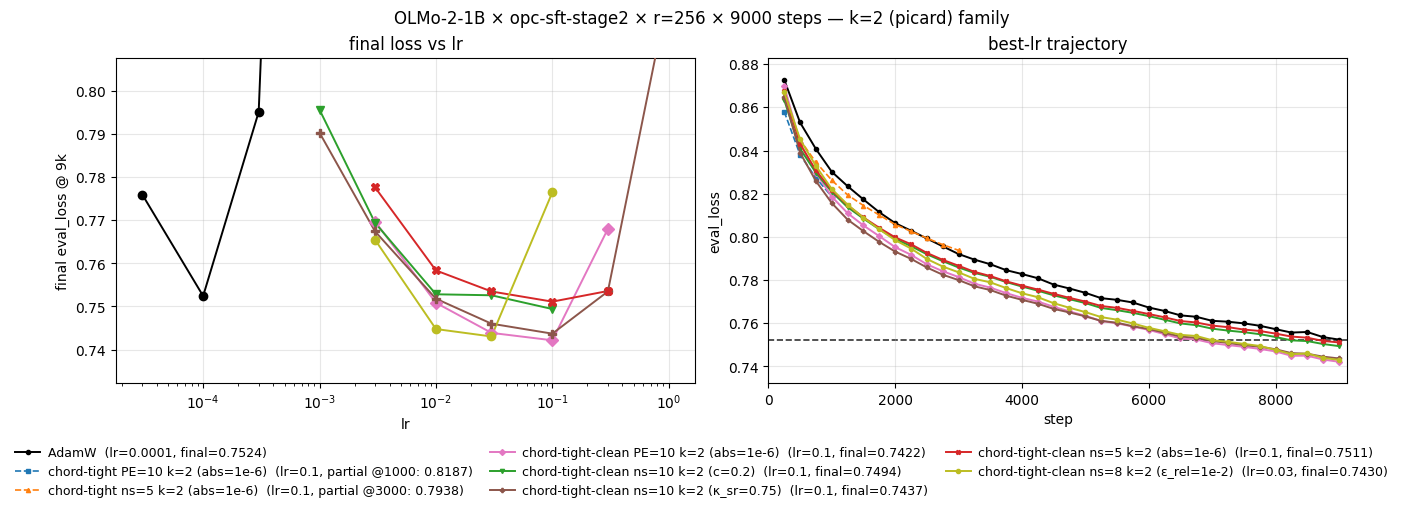

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.752439,NaN,NaN
1,chord-tight-clean PE=10 k=2 (abs=1e-6),0.1000,0.742152,-0.010287,-6.051002
2,chord-tight-clean ns=10 k=2 (c=0.2),0.1000,0.749414,-0.003025,-1.779405
3,chord-tight-clean ns=10 k=2 (κ_sr=0.75),0.1000,0.743693,-0.008745,-5.144276
4,chord-tight-clean ns=5 k=2 (abs=1e-6),0.1000,0.751126,-0.001312,-0.772037
5,chord-tight-clean ns=8 k=2 (ε_rel=1e-2),0.0300,0.743038,-0.009400,-5.529625


In [7]:
_fig, _tdf, sdf = leaderboard_panel('allenai/OLMo-2-0425-1B', 'opc', 256,
    'OLMo-2-1B × opc-sft-stage2 × r=256 × 9000 steps — k=2 (picard) family',
    label_filter=lambda l, c: l == 'AdamW' or (picard_of(c) == 2 and not is_curv(l)),
    figsize=(13, 5))
plt.show()
sdf